# Análise Exploratória — 75 anos de Fórmula 1 (1950-2024)

Este notebook explora um dataset relacional (schema clássico estilo Ergast) com
**1.125 corridas**, **861 pilotos**, **174 famílias de construtores** e **35 países**,
cobrindo toda a história do campeonato mundial de F1, de 1950 até o fim da
temporada de 2024.

O objetivo aqui não é só gerar gráficos bonitos — é entender a forma dos dados,
documentar decisões de limpeza/transformação, e extrair os insights que depois
alimentam o dashboard interativo (`dashboard/app.py`).

**Pipeline:** os dados brutos (`data/raw/*.csv`) passam por um script de ETL
(`etl/build_processed_data.py`) que limpa, junta e agrega tudo em tabelas
Parquet (`data/processed/`). Este notebook consome exclusivamente essas
tabelas já processadas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

DATA = Path("..") / "data" / "processed"

# Paleta escura inspirada nos telões de tempo da F1 (roxo = volta mais rápida,
# verde = melhor pessoal), usada também no dashboard para manter consistência.
BG, PANEL = "#0B0E14", "#12161F"
TEXT, MUTED = "#E8E9ED", "#8B92A0"
PURPLE, GREEN, AMBER, RED = "#A855F7", "#00D68F", "#F5A623", "#FF5C5C"
GRID = "#242A36"
PALETTE = [PURPLE, GREEN, AMBER, "#4EA8DE", RED, "#E8E9ED", "#7C83FD", "#FF8FB1"]

mpl.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT, "text.color": TEXT,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "font.family": "DejaVu Sans",
    "font.size": 11, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.facecolor": PANEL, "legend.edgecolor": GRID, "figure.dpi": 110,
})
pd.set_option("display.max_columns", None)

## 1. Carregando as tabelas processadas

In [2]:
fact_results = pd.read_parquet(DATA / "fact_results.parquet")
fact_sprint_results = pd.read_parquet(DATA / "fact_sprint_results.parquet")
fact_qualifying = pd.read_parquet(DATA / "fact_qualifying.parquet")
fact_pitstops = pd.read_parquet(DATA / "fact_pitstops.parquet")
dim_drivers = pd.read_parquet(DATA / "dim_drivers.parquet")
dim_races = pd.read_parquet(DATA / "dim_races.parquet")
dim_circuits = pd.read_parquet(DATA / "dim_circuits.parquet")
agg_driver_career = pd.read_parquet(DATA / "agg_driver_career.parquet")
agg_constructor_career = pd.read_parquet(DATA / "agg_constructor_career.parquet")
agg_constructor_season = pd.read_parquet(DATA / "agg_constructor_season.parquet")
agg_circuit_stats = pd.read_parquet(DATA / "agg_circuit_stats.parquet")
season_champions = pd.read_parquet(DATA / "season_champions.parquet")

print(f"{dim_races['season'].nunique()} temporadas · {dim_races['raceId'].nunique()} corridas · "
      f"{fact_results['driverId'].nunique()} pilotos · {fact_results['constructor_family'].nunique()} equipes (agrupadas) · "
      f"{dim_races['circuitCountry'].nunique()} países-sede")
fact_results.head()

75 temporadas · 1125 corridas · 861 pilotos · 174 equipes (agrupadas) · 35 países-sede


,raceId,season,round,decade,date,circuitCountry,driverId,driverFullName,driverNationality,constructorId,constructorName,constructor_family,constructorNationality,grid,position,positionText,points,sprint_points,total_points,laps,status,status_category,classified,is_win,is_podium,is_top10,points_finish,position_gained,fastestLapRank,fastestLap_lap,fastestLapTime_sec,is_sprint_weekend
0,1950_01,1950,1,1950,1950-05-13,UK,farina,Nino Farina,Italian,alfa,Alfa Romeo,Alfa Romeo,Swiss,1,1,1,9.0,0.0,9.0,70,Finished,Finished,True,True,True,True,True,0.0,NaN,NaN,NaN,False
1,1950_01,1950,1,1950,1950-05-13,UK,fagioli,Luigi Fagioli,Italian,alfa,Alfa Romeo,Alfa Romeo,Swiss,2,2,2,6.0,0.0,6.0,70,Finished,Finished,True,False,True,True,True,0.0,NaN,NaN,NaN,False
2,1950_01,1950,1,1950,1950-05-13,UK,reg_parnell,Reg Parnell,British,alfa,Alfa Romeo,Alfa Romeo,Swiss,4,3,3,4.0,0.0,4.0,70,Finished,Finished,True,False,True,True,True,1.0,NaN,NaN,NaN,False
3,1950_01,1950,1,1950,1950-05-13,UK,cabantous,Yves Cabantous,French,lago,Talbot-Lago,Talbot,French,6,4,4,3.0,0.0,3.0,68,+2 Laps,Finished,True,False,False,True,True,2.0,NaN,NaN,NaN,False
4,1950_01,1950,1,1950,1950-05-13,UK,rosier,Louis Rosier,French,lago,Talbot-Lago,Talbot,French,9,5,5,2.0,0.0,2.0,68,+2 Laps,Finished,True,False,False,True,True,4.0,NaN,NaN,NaN,False


## 2. Notas sobre qualidade e integridade dos dados

Antes de qualquer gráfico, vale documentar três decisões importantes que
mudam o resultado se ignoradas:

**a) Pontos de sprint race não vinham junto.** Desde 2021 a F1 tem corridas
sprint que também valem pontos de campeonato, mas eles ficam num arquivo
separado (`sprint_results.csv`). Sem somar isso, o total de pontos de 2021
do Verstappen aparecia **7 pontos a menos** do que o real — o suficiente pra
distorcer visualmente quem estava "na frente" naquele título disputado até a
última volta. O pipeline já soma `points` (só corrida) + `sprint_points` =
`total_points`.

**b) "Somar todos os pontos da temporada" nem sempre dá o campeão certo.**
As regras de pontuação mudaram várias vezes ao longo da história — em boa
parte das décadas de 1950 a 1980 só contavam os N melhores resultados da
temporada (sistema de descarte). Testando: se eu calculasse o campeão apenas
somando pontos de todas as corridas, eu erraria em **5 das 75 temporadas**
(1961, 1964, 1970, 1977 e 1988) — em 1964 e 1988, inclusive, o campeão real
teve **menos** pontos somados que o vice. Por isso a lista de campeões usada
aqui (`season_champions`) foi verificada contra uma fonte externa confiável,
em vez de derivada por soma.

**c) Corridas com "piloto duplicado".** Em 42 corridas entre 1950-1962 (e uma
vez em 1978), o mesmo piloto aparece duas vezes na classificação de uma
mesma prova — não é erro, é o carona (*shared drive*), prática permitida na
época em que um piloto podia assumir o carro de um companheiro de equipe
após abandonar o seu. O caso mais famoso: Fangio e Fagioli dividiram o carro
vencedor do GP da França de 1951. As agregações abaixo (`nunique` de corrida,
soma de indicador de vitória) já são robustas a isso.

In [3]:
mismatches = []
dsp = pd.read_parquet(DATA / "driver_standings_progression.parquet")
for _, row in season_champions.iterrows():
    season = row["season"]
    final_round = dsp.loc[dsp["season"] == season, "round"].max()
    leader = (dsp[(dsp["season"] == season) & (dsp["round"] == final_round)]
              .sort_values("points_cum", ascending=False).iloc[0])
    if leader["driverId"] != row["champion_driverId"]:
        mismatches.append((season, row["champion_driver_name"], leader["driverFullName"]))

print(f"Temporadas em que 'soma de pontos' != campeão oficial: {len(mismatches)}")
for season, real, by_points in mismatches:
    print(f"  {season}: campeão real = {real:<20s} | líder por soma de pontos = {by_points}")

Temporadas em que 'soma de pontos' != campeão oficial: 5
  1961: campeão real = Phil Hill            | líder por soma de pontos = Dan Gurney
  1964: campeão real = John Surtees         | líder por soma de pontos = Graham Hill
  1970: campeão real = Jochen Rindt         | líder por soma de pontos = Jacky Ickx
  1977: campeão real = Niki Lauda           | líder por soma de pontos = Jody Scheckter
  1988: campeão real = Ayrton Senna         | líder por soma de pontos = Alain Prost


## 3. Como o esporte cresceu

O calendário praticamente dobrou de tamanho e o grid de pilotos por
temporada mudou bastante de perfil ao longo de 75 anos.

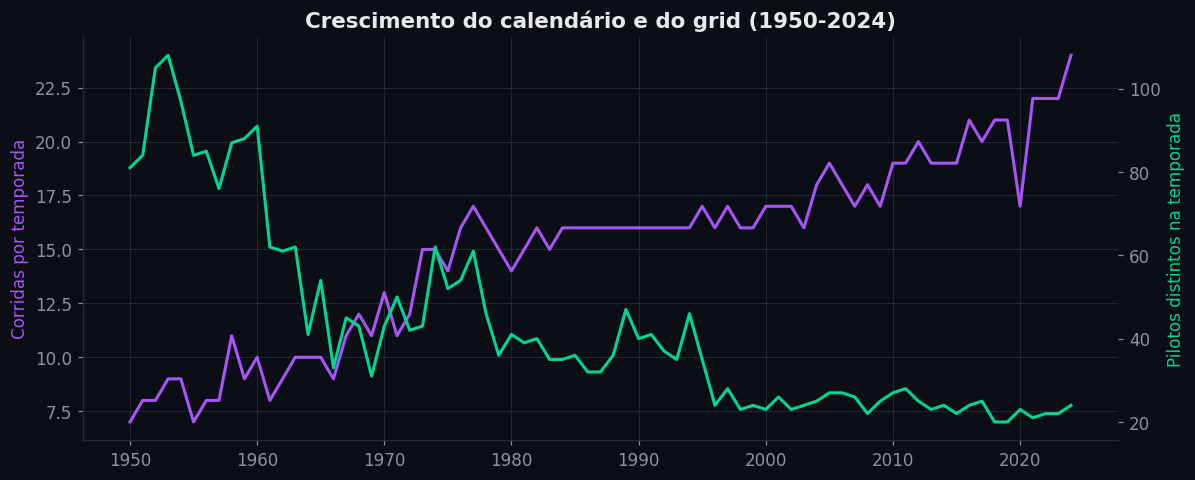

1950: 7 corridas, 81 pilotos  ->  2024: 24 corridas, 24 pilotos


In [4]:
g = fact_results.groupby("season").agg(races=("raceId", "nunique"), drivers=("driverId", "nunique"))

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(g.index, g["races"], color=PURPLE, lw=2)
ax1.set_ylabel("Corridas por temporada", color=PURPLE)
ax2 = ax1.twinx()
ax2.plot(g.index, g["drivers"], color=GREEN, lw=2)
ax2.set_ylabel("Pilotos distintos na temporada", color=GREEN)
ax2.grid(False)
ax1.set_title("Crescimento do calendário e do grid (1950-2024)")
fig.tight_layout()
plt.show()

print(f"1950: {g.loc[1950,'races']} corridas, {g.loc[1950,'drivers']} pilotos  ->  "
      f"2024: {g.loc[2024,'races']} corridas, {g.loc[2024,'drivers']} pilotos")

## 4. Quem dominou: pilotos e construtores

Vitórias e títulos contam histórias um pouco diferentes — vitórias recompensam
longevidade e velocidade de carro; títulos recompensam consistência numa
temporada específica.

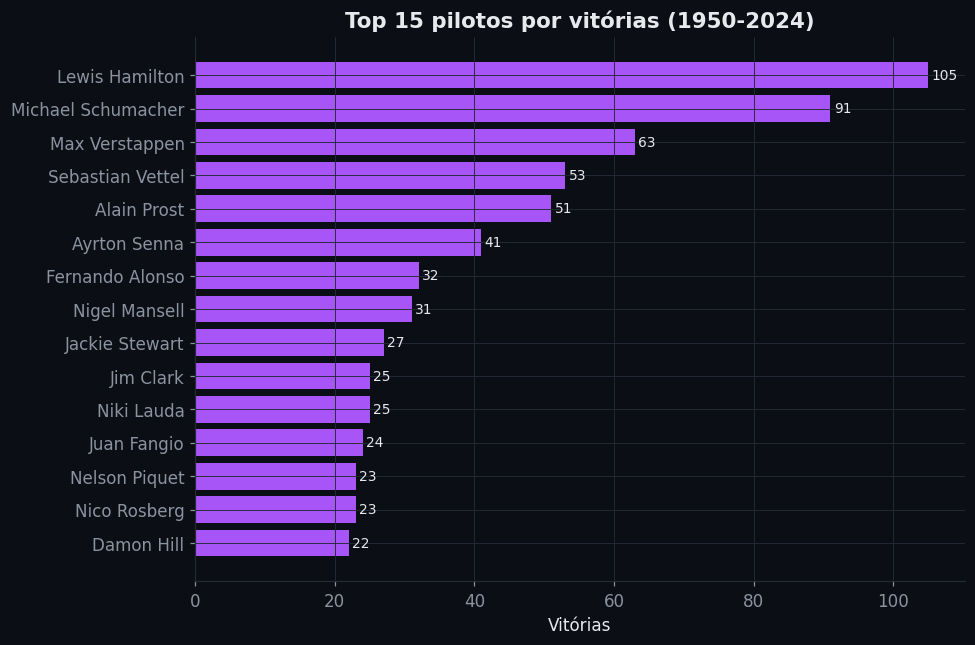

In [5]:
top15 = agg_driver_career.sort_values("wins", ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15["fullName"], top15["wins"], color=PURPLE)
for b, w in zip(bars, top15["wins"]):
    ax.text(w + 0.5, b.get_y() + b.get_height() / 2, str(int(w)), va="center", fontsize=9)
ax.set_title("Top 15 pilotos por vitórias (1950-2024)")
ax.set_xlabel("Vitórias")
fig.tight_layout()
plt.show()

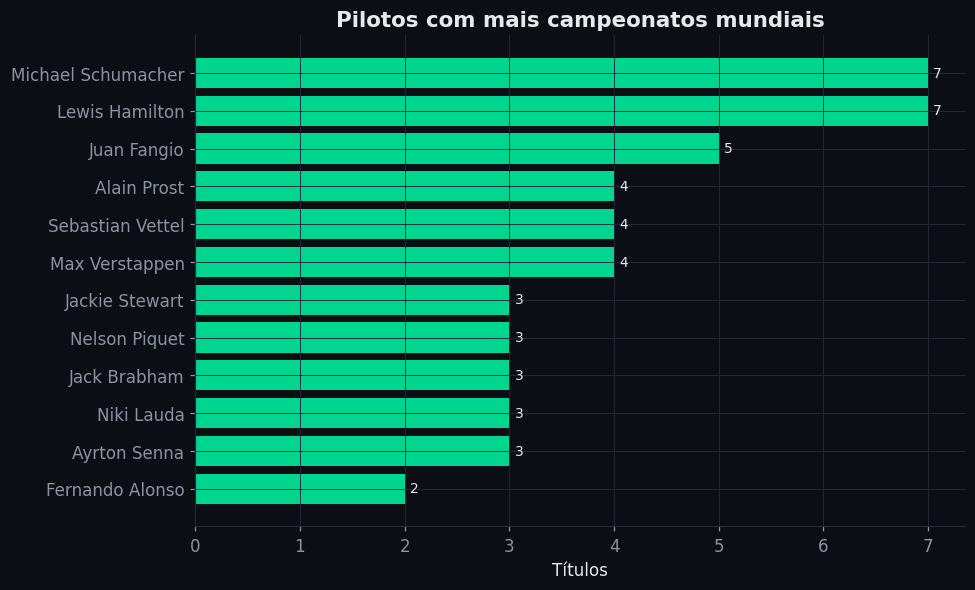

In [6]:
champs = agg_driver_career[agg_driver_career["championships"] > 0] \
    .sort_values("championships", ascending=False).head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(champs["fullName"], champs["championships"], color=GREEN)
for b, w in zip(bars, champs["championships"]):
    ax.text(w + 0.05, b.get_y() + b.get_height() / 2, str(int(w)), va="center", fontsize=9)
ax.set_title("Pilotos com mais campeonatos mundiais")
ax.set_xlabel("Títulos")
fig.tight_layout()
plt.show()

In [7]:
cc = agg_constructor_career.sort_values("championships", ascending=False).head(8)
print(cc[["constructor_family", "championships", "wins", "points"]].to_string(index=False))

constructor_family  championships  wins   points
           Ferrari             16   249 11227.27
           McLaren              9   189  7275.50
          Williams              9   114  3643.00
          Mercedes              8   129  7829.64
             Lotus              7    34   519.00
          Red Bull              6   122  7837.00
            Cooper              2    16   494.50
           Renault              2    35  1777.00


## 5. Largada define a corrida?

Correlação entre posição de largada (grid) e posição final — e o quanto os
pilotos conseguem ganhar ou perder posições ao longo da corrida.

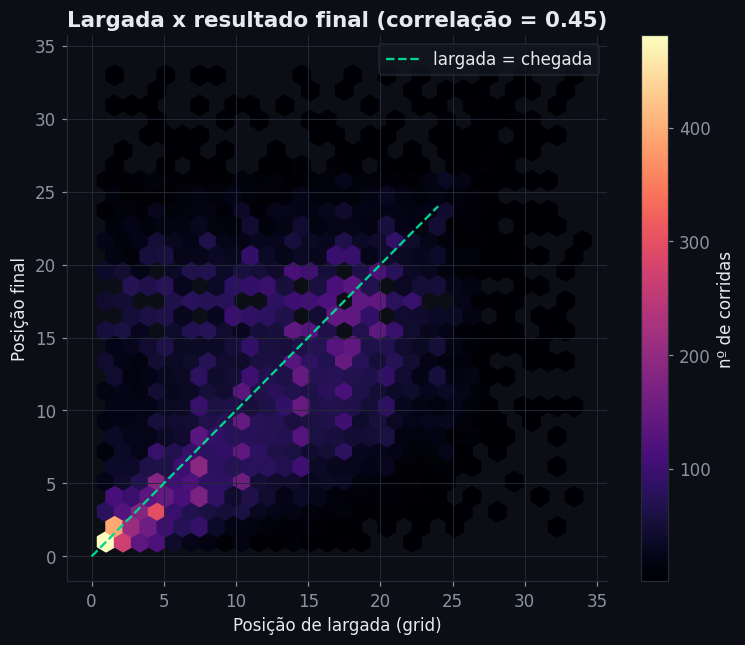

Correlação grid-posição final: 0.45 — forte o bastante pra grid importar, longe de 1.0: sobra bastante corrida pra acontecer depois da largada.


In [8]:
sample = fact_results[(fact_results["grid"] > 0) & (fact_results["position"] > 0)]
corr = sample[["grid", "position"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 6))
hb = ax.hexbin(sample["grid"], sample["position"], gridsize=28, cmap="magma", mincnt=1)
ax.plot([0, 24], [0, 24], color=GREEN, lw=1.5, ls="--", label="largada = chegada")
ax.set_xlabel("Posição de largada (grid)")
ax.set_ylabel("Posição final")
ax.set_title(f"Largada x resultado final (correlação = {corr:.2f})")
ax.legend()
fig.colorbar(hb, ax=ax, label="nº de corridas")
fig.tight_layout()
plt.show()

print(f"Correlação grid-posição final: {corr:.2f} — forte o bastante pra grid importar, "
      "longe de 1.0: sobra bastante corrida pra acontecer depois da largada.")

## 6. Confiabilidade e segurança ao longo do tempo

A taxa de "não-classificação" (carro que não terminou rodando, por qualquer
motivo — mecânico, acidente, desclassificação) caiu de forma consistente.
Isso reflete tanto evolução de confiabilidade mecânica quanto, principalmente
nas décadas mais antigas, a natureza muito mais perigosa e imprevisível do
esporte.

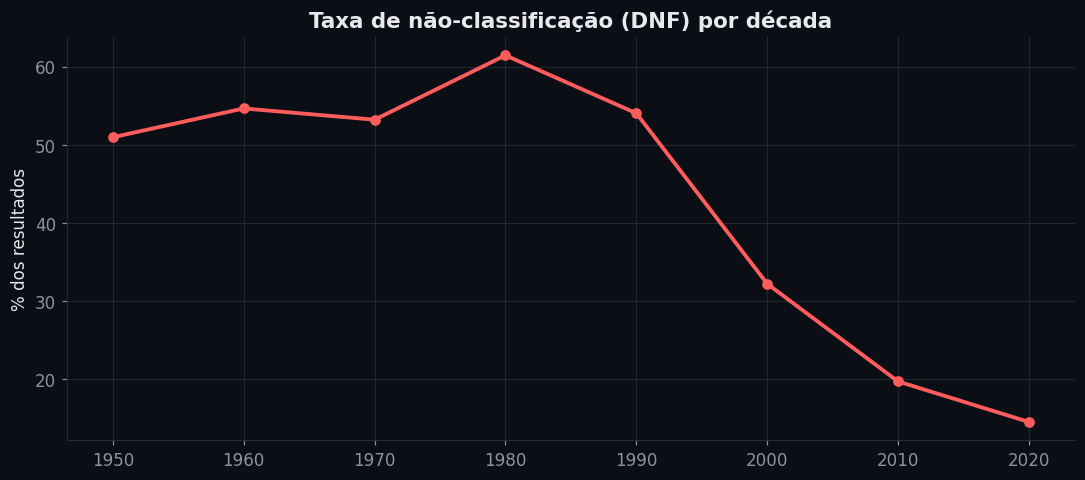

Década de 1950: 51.0% dos carros não terminavam classificados. Década de 2020: 14.5%.


In [9]:
dnf = fact_results.groupby("decade").apply(lambda d: (~d["classified"]).mean() * 100, include_groups=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(dnf.index, dnf.values, color=RED, lw=2.5, marker="o")
ax.set_title("Taxa de não-classificação (DNF) por década")
ax.set_ylabel("% dos resultados")
ax.set_xticks(dnf.index)
fig.tight_layout()
plt.show()

print(f"Década de 1950: {dnf.loc[1950]:.1f}% dos carros não terminavam classificados. "
      f"Década de 2020: {dnf.loc[2020]:.1f}%.")

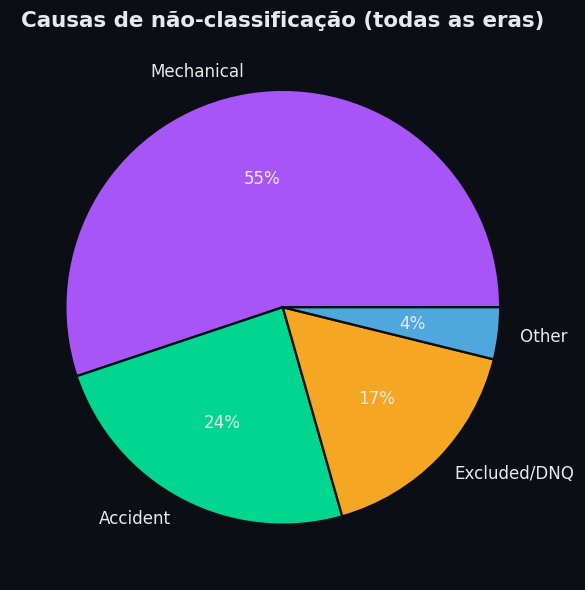

In [10]:
causes = fact_results[~fact_results["classified"]]["status_category"].value_counts()
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.pie(causes.values, labels=causes.index, autopct="%1.0f%%", colors=PALETTE,
       textprops={"color": TEXT}, wedgeprops={"edgecolor": BG, "linewidth": 1.5})
ax.set_title("Causas de não-classificação (todas as eras)")
fig.tight_layout()
plt.show()

## 7. Os carros ficaram mais rápidos?

Comparar tempo de volta "no geral" entre temporadas é enganoso — cada ano
tem um calendário de circuitos diferente, com comprimentos diferentes. A
forma correta é comparar o **mesmo circuito** ao longo dos anos. Monza
(Autódromo Nacional de Monza) é o melhor candidato: sediou 74 das 75
temporadas, praticamente sem interrupção.

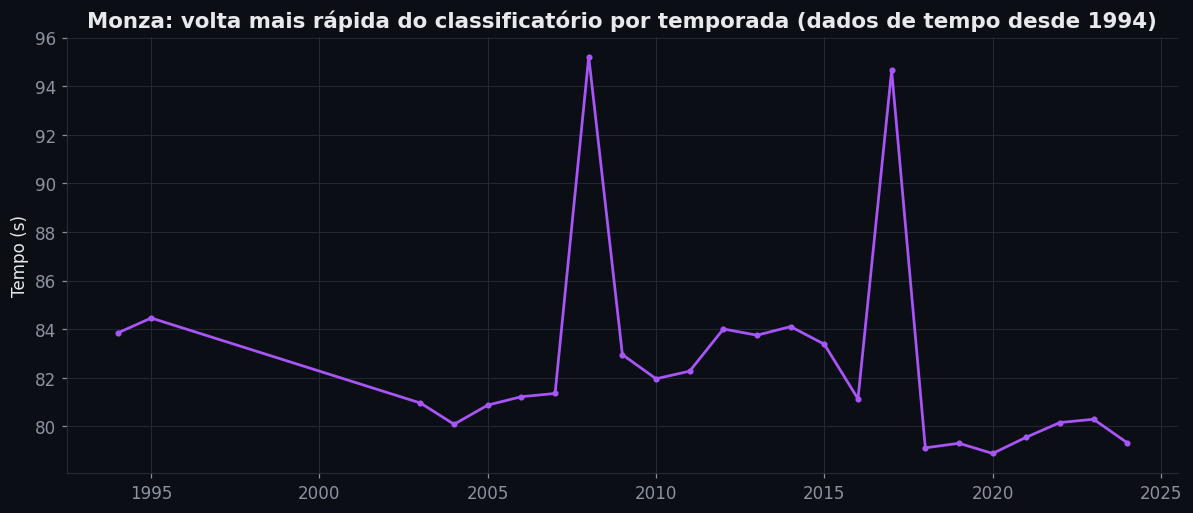

2020: volta mais rápida registrada em Monza, 78.89s


In [11]:
monza_race_ids = dim_races.loc[dim_races["circuitId"] == "monza", "raceId"]
q_monza = fact_qualifying[fact_qualifying["raceId"].isin(monza_race_ids)]
monza_best = q_monza.groupby("season")["best_time_sec"].min().dropna()

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(monza_best.index, monza_best.values, color=PURPLE, lw=1.8, marker="o", ms=3)
ax.set_title("Monza: volta mais rápida do classificatório por temporada (dados de tempo desde 1994)")
ax.set_ylabel("Tempo (s)")
fig.tight_layout()
plt.show()

print(f"{monza_best.idxmin()}: volta mais rápida registrada em Monza, {monza_best.min():.2f}s")

## 8. Pit stops: mito do "cada vez mais rápido"?

Um estereótipo popular é que os pit stops só ficam mais rápidos a cada ano —
os recordes de troca de pneu (abaixo de 2 segundos) reforçam essa ideia. Mas
o campo `duration` deste dataset mede o **tempo total no pit lane** (da
entrada à saída), não só o tempo parado trocando pneu — e por esse ângulo a
história é bem menos dramática.

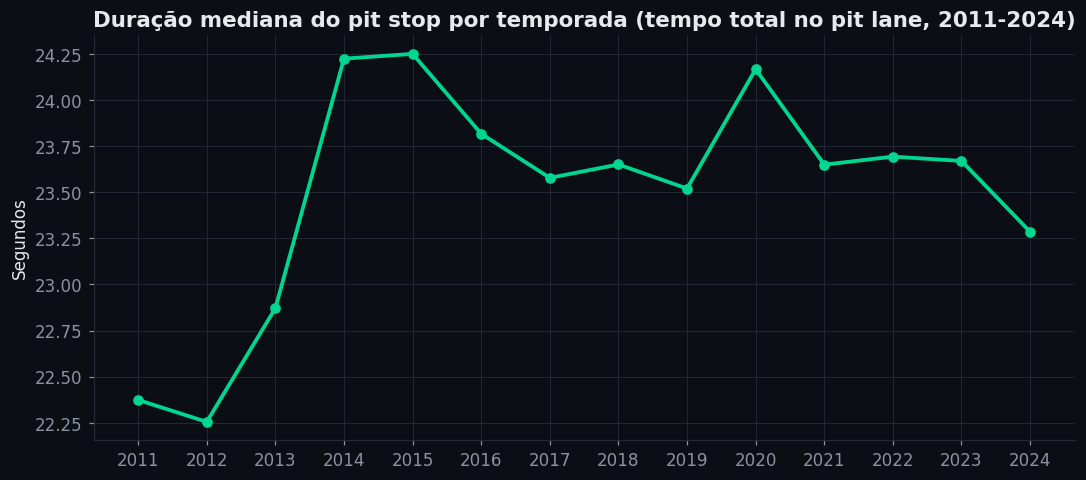

Mediana 2011: 22.4s  ->  mediana 2024: 23.3s
Praticamente estável: o pit lane em si (limite de velocidade + distância) não mudou muito;
os ganhos de velocidade na troca de pneu em si são pequenos frente ao tempo total de trânsito.


In [12]:
ps_trend = fact_pitstops.groupby("season")["duration_sec"].median()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ps_trend.index, ps_trend.values, color=GREEN, lw=2.5, marker="o")
ax.set_title("Duração mediana do pit stop por temporada (tempo total no pit lane, 2011-2024)")
ax.set_ylabel("Segundos")
ax.set_xticks(ps_trend.index.astype(int))
fig.tight_layout()
plt.show()

print(f"Mediana 2011: {ps_trend.iloc[0]:.1f}s  ->  mediana 2024: {ps_trend.iloc[-1]:.1f}s")
print("Praticamente estável: o pit lane em si (limite de velocidade + distância) não mudou muito;")
print("os ganhos de velocidade na troca de pneu em si são pequenos frente ao tempo total de trânsito.")

## 9. Domínio por equipe ao longo das eras

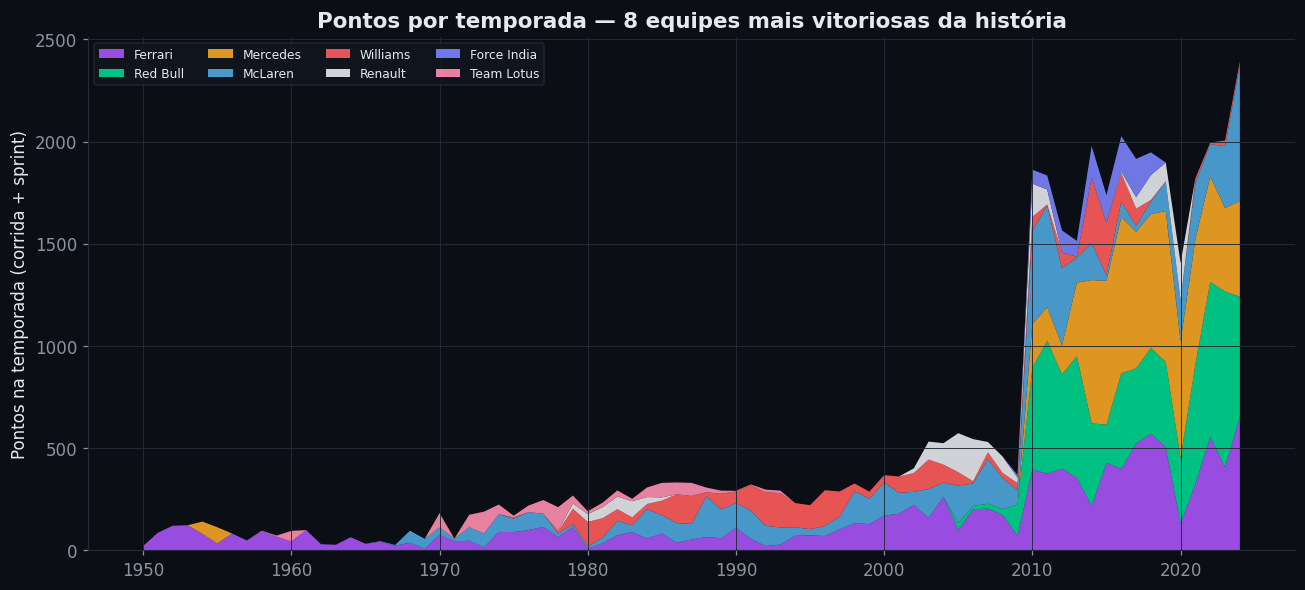

In [13]:
cs = agg_constructor_season.copy()
top_teams = cs.groupby("constructor_family")["points"].sum().sort_values(ascending=False).head(8).index.tolist()
pivot = cs[cs["constructor_family"].isin(top_teams)].pivot_table(
    index="season", columns="constructor_family", values="points", aggfunc="sum"
).fillna(0)[top_teams]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.stackplot(pivot.index, pivot.values.T, labels=pivot.columns,
             colors=(PALETTE * 2)[:len(top_teams)], alpha=0.9)
ax.set_title("Pontos por temporada — 8 equipes mais vitoriosas da história")
ax.legend(loc="upper left", ncol=4, fontsize=8)
ax.set_ylabel("Pontos na temporada (corrida + sprint)")
fig.tight_layout()
plt.show()

## 10. De onde vêm os pilotos (e uma pegadinha histórica)

Reino Unido e Estados Unidos lideram o ranking de nacionalidades — mas o
número americano é enganoso.

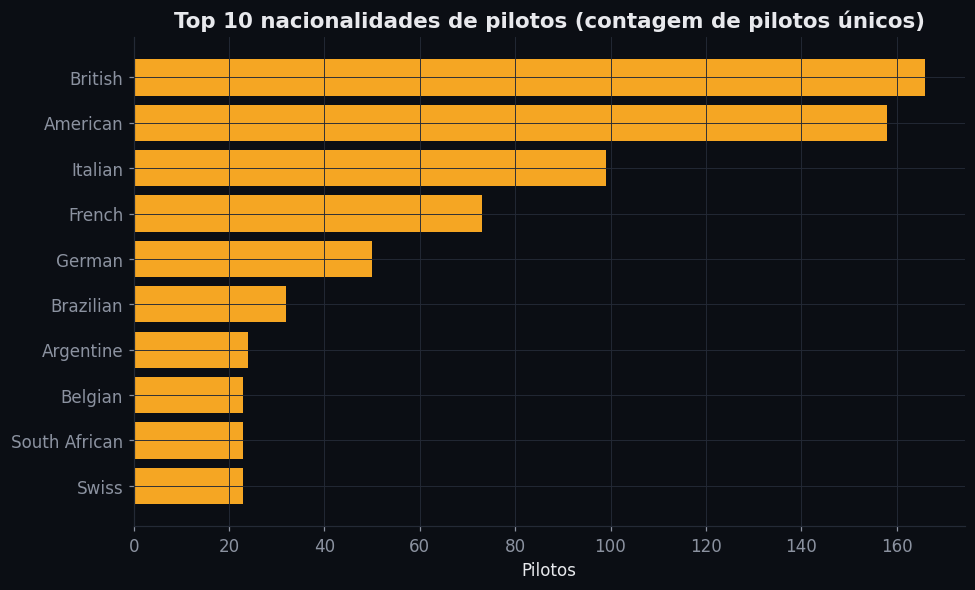

In [14]:
nat_counts = dim_drivers["nationality"].value_counts().head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(nat_counts.index, nat_counts.values, color=AMBER)
ax.set_title("Top 10 nacionalidades de pilotos (contagem de pilotos únicos)")
ax.set_xlabel("Pilotos")
fig.tight_layout()
plt.show()

In [15]:
indy_race_ids = dim_races.loc[dim_races["raceName"].str.contains("Indianapolis", na=False), "raceId"]
american_ids = dim_drivers.loc[dim_drivers["nationality"] == "American", "driverId"]
fr_american = fact_results[fact_results["driverId"].isin(american_ids)]
only_indy = fr_american.groupby("driverId")["raceId"].apply(lambda ids: set(ids).issubset(set(indy_race_ids)))

print(f"Dos {len(only_indy)} pilotos americanos no dataset, {only_indy.sum()} correram "
      "SOMENTE edições da Indy 500.")
print("A Indy 500 fez parte do calendário oficial do campeonato mundial de F1 entre 1950 e 1960,")
print("mesmo sendo disputada por uma categoria totalmente diferente (o que era a Indy da época).")
print("Sem esse contexto, a Fórmula 1 pareceria muito mais 'americana' nos anos 1950 do que realmente foi.")

Dos 158 pilotos americanos no dataset, 103 correram SOMENTE edições da Indy 500.
A Indy 500 fez parte do calendário oficial do campeonato mundial de F1 entre 1950 e 1960,
mesmo sendo disputada por uma categoria totalmente diferente (o que era a Indy da época).
Sem esse contexto, a Fórmula 1 pareceria muito mais 'americana' nos anos 1950 do que realmente foi.


## 11. Circuitos: quem sediou mais corridas

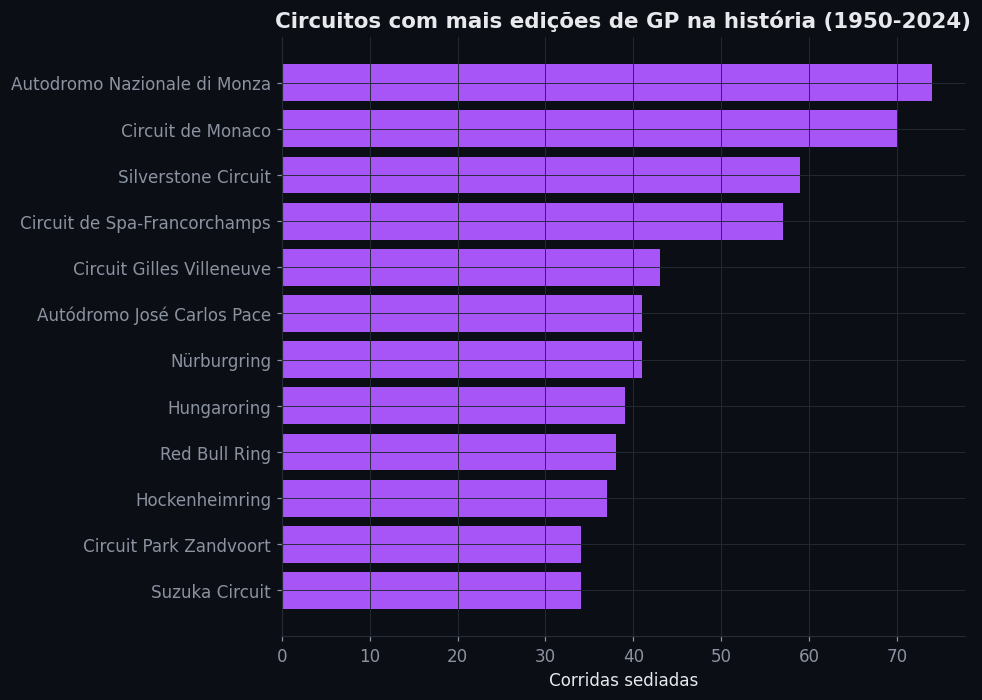

In [16]:
top_circuits = agg_circuit_stats.sort_values("races_held", ascending=False).head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(top_circuits["circuitName"], top_circuits["races_held"], color=PURPLE)
ax.set_title("Circuitos com mais edições de GP na história (1950-2024)")
ax.set_xlabel("Corridas sediadas")
fig.tight_layout()
plt.show()

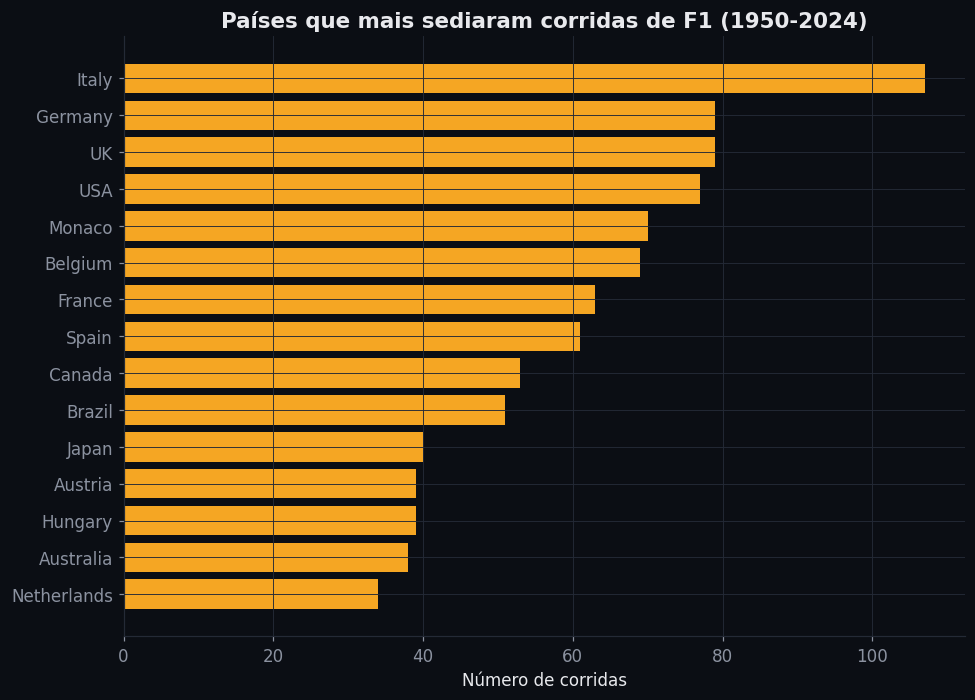

In [17]:
country_races = dim_races.groupby("circuitCountry")["raceId"].nunique().sort_values(ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(country_races.index, country_races.values, color=AMBER)
ax.set_title("Países que mais sediaram corridas de F1 (1950-2024)")
ax.set_xlabel("Número de corridas")
fig.tight_layout()
plt.show()

## 12. Resumo dos principais insights

- **Confiabilidade/segurança:** taxa de DNF caiu de ~51% (anos 1950) para
  ~15% (anos 2020) — a mudança estrutural mais forte de toda a história do
  esporte.
- **Largada importa, mas não decide:** correlação de ~0.45 entre grid e
  posição final — forte o bastante pra qualificação valer, fraca o
  bastante pra corrida ainda ter emoção.
- **Ferrari é a equipe mais vitoriosa da história** (16 títulos de
  construtores, 249 vitórias), mas a dominância por era é bem distribuída
  (Lotus/Cooper anos 60, McLaren/Williams 80-90, Ferrari anos 2000,
  Mercedes/Red Bull era híbrida).
- **Pontos de sprint e regras de pontuação históricas são pegadinhas reais**
  de engenharia de dados neste domínio — ignorá-las produz números errados
  de forma silenciosa, sem erro nenhum no código.
- **Pit stops não ficaram dramaticamente mais rápidos** quando medidos por
  tempo total de pit lane (ao contrário do que a percepção popular sobre
  "troca de pneu recorde" sugere).

Essas descobertas (e as tabelas processadas que as geraram) alimentam
diretamente o dashboard interativo em `dashboard/app.py`.